In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np


In [2]:
data = pd.read_csv('../data/Processed_Project_Data/fifa_and_elo_rankings_clean_filled.csv')
data.drop(columns = ['Unnamed: 0'], inplace = True)

In [3]:
data[['home_elo', 'away_elo', 'elo_advantage']]

,home_elo,away_elo,elo_advantage
0,1578.0,1839.0,-261.0
1,1813.0,2101.0,-288.0
2,1729.0,1847.0,-118.0
3,1849.0,2149.0,-300.0
4,1629.0,1496.0,133.0
...,...,...,...
1234,1622.0,1627.0,-5.0
1235,1840.0,1627.0,213.0
1236,1807.0,1622.0,185.0
1237,1622.0,1627.0,-5.0


In [4]:
X = data[['elo_advantage']]
y = data['result']

label_mapping = {
    -1:0,
    0:1,
    1:2
}

y_enc = y.map(label_mapping)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42, stratify = y_enc)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [6]:
X_train_tensor = torch.tensor(X_train_s, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_s, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype = torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype = torch.long)

In [7]:
from experiment_utils import run_one_experiment, save_result, run, MLPClassifier, save_result_v1

In [ ]:
import random
import numpy as np

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

input_dim = X_train_tensor.shape[1]

model = MLPClassifier(input_dim=input_dim)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

Epoch 50/1000 | train loss = 0.8209 | val loss = 0.8522 | val acc = 0.6030
Epoch 100/1000 | train loss = 0.8198 | val loss = 0.8501 | val acc = 0.6030
Epoch 150/1000 | train loss = 0.8138 | val loss = 0.8521 | val acc = 0.5980
Epoch 200/1000 | train loss = 0.8172 | val loss = 0.8512 | val acc = 0.6030
Epoch 250/1000 | train loss = 0.8203 | val loss = 0.8488 | val acc = 0.6030
Epoch 300/1000 | train loss = 0.8080 | val loss = 0.8490 | val acc = 0.6080
Epoch 350/1000 | train loss = 0.8180 | val loss = 0.8498 | val acc = 0.6030
Epoch 400/1000 | train loss = 0.8245 | val loss = 0.8500 | val acc = 0.6080
Epoch 450/1000 | train loss = 0.8166 | val loss = 0.8505 | val acc = 0.6080
Epoch 500/1000 | train loss = 0.8154 | val loss = 0.8513 | val acc = 0.6080
Epoch 550/1000 | train loss = 0.8087 | val loss = 0.8513 | val acc = 0.6181
Epoch 600/1000 | train loss = 0.8152 | val loss = 0.8464 | val acc = 0.6080
Epoch 650/1000 | train loss = 0.8180 | val loss = 0.8502 | val acc = 0.6231
Epoch 700/100

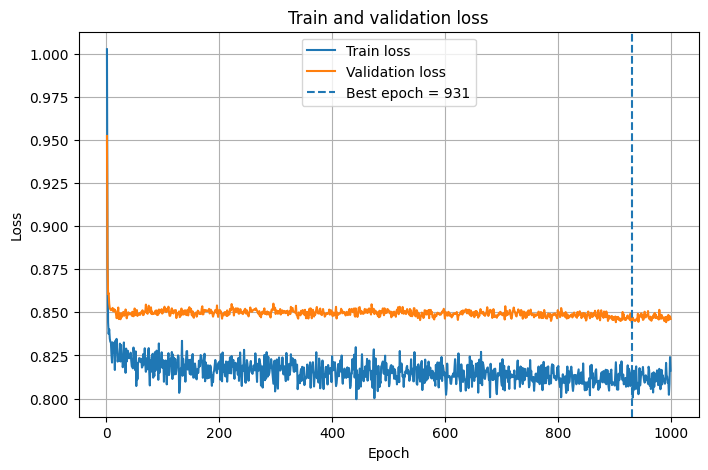

0.5725806451612904

In [11]:
run_one_experiment(model, criterion, optimizer, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor)

In [12]:
best_num_epochs = 931

summary, results_df = run(
    model_class=MLPClassifier,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    X_test_tensor=X_test_tensor,
    y_test_tensor=y_test_tensor,
    num_epochs=best_num_epochs,
)

Run 1/10
Accuracy: 0.5726 | Precision: 0.4779 | Recall: 0.4987 | Specificity: 0.7723 | F1: 0.4841

Run 2/10
Accuracy: 0.5927 | Precision: 0.4701 | Recall: 0.5089 | Specificity: 0.7760 | F1: 0.4727

Run 3/10
Accuracy: 0.5766 | Precision: 0.4737 | Recall: 0.5019 | Specificity: 0.7731 | F1: 0.4823

Run 4/10
Accuracy: 0.5766 | Precision: 0.4523 | Recall: 0.4975 | Specificity: 0.7714 | F1: 0.4665

Run 5/10
Accuracy: 0.5806 | Precision: 0.4663 | Recall: 0.5017 | Specificity: 0.7737 | F1: 0.4763

Run 6/10
Accuracy: 0.6089 | Precision: 0.5016 | Recall: 0.5217 | Specificity: 0.7823 | F1: 0.4901

Run 7/10
Accuracy: 0.5766 | Precision: 0.4870 | Recall: 0.5046 | Specificity: 0.7757 | F1: 0.4922

Run 8/10
Accuracy: 0.5847 | Precision: 0.4991 | Recall: 0.5166 | Specificity: 0.7822 | F1: 0.5049

Run 9/10
Accuracy: 0.5685 | Precision: 0.4463 | Recall: 0.4902 | Specificity: 0.7688 | F1: 0.4619

Run 10/10
Accuracy: 0.5726 | Precision: 0.4610 | Recall: 0.4960 | Specificity: 0.7718 | F1: 0.4733

Summary o

In [13]:
save_result(
    experiment_name="Experiment_1-4_ELO_diff",
    summary=summary
)

save_result_v1(
    experiment_name="Experiment_1-4_ELO_diff",
    summary=summary
)


Saved result for Experiment_1-4_ELO_diff
File: ../results/experiment_summary_final.csv

Saved result for Experiment_1-4_ELO_diff
File: ../results/experiment_summary_v1.csv
